# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [4]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0,  
    'close_confidence': 0.2,  
    'standard_num': 1000,
    'trailing_stop_pct': 0.001,
    'max_pct': 0.004,
    'min_pct': 0.001,

    'k_pct': 1,
    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 日期分割方法说明

本notebook提供了两种日期分割方法：

### 方法1：按天数分割（原来的方法）
```python
train_dates, valid_dates, test_dates = split_dates(trade_dates, 45, 15, 17)
```
**特点**：
- 简单直接，按固定天数分配
- 训练集：前45天
- 验证集：中间15天  
- 测试集：最后17天

### 方法2：按日期范围分割（新的灵活方法）
```python
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20251201",  # 训练集开始日期
    train_end="20260203",    # 训练集结束日期
    valid_start="20260204",  # 验证集开始日期
    valid_end="20260304",    # 验证集结束日期
    test_start="20260305",   # 测试集开始日期
    test_end="20260327"      # 测试集结束日期
)
```
**优势**：
1. **灵活性**：可以指定具体的日期范围，不限于连续的天数
2. **精确控制**：可以跳过节假日或特定日期
3. **可重复性**：使用固定日期范围确保结果可重复
4. **时间序列完整性**：保持时间序列的连续性，避免未来信息泄露

**使用建议**：
- 研究阶段：使用方法2，确保日期范围固定，结果可比较
- 快速测试：使用方法1，简单快捷


## 获取交易日数据

In [5]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20251201",  # 训练集开始日期
    train_end="20260203",    # 训练集结束日期
    valid_start="20260204",  # 验证集开始日期
    valid_end="20260304",    # 验证集结束日期
    test_start="20260305",   # 测试集开始日期
    test_end="20260327"      # 测试集结束日期
)

总交易日数量: 77
交易日范围: 20251201 ~ 20260327
训练集: 20251201 ~ 20260203 (45天)
验证集: 20260204 ~ 20260304 (15天)
测试集: 20260305 ~ 20260327 (17天)


## 生成训练数据

In [6]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20251201: 产生 805 个样本
20251202: 产生 794 个样本
20251203: 产生 791 个样本
20251204: 产生 778 个样本
20251205: 产生 813 个样本
20251208: 产生 803 个样本
20251209: 产生 858 个样本
20251210: 产生 754 个样本
20251211: 产生 807 个样本
20251212: 产生 766 个样本
20251215: 产生 809 个样本
20251216: 产生 865 个样本
20251217: 产生 808 个样本
20251218: 产生 787 个样本
20251219: 产生 769 个样本
20251222: 产生 821 个样本
20251223: 产生 857 个样本
20251224: 产生 803 个样本
20251225: 产生 821 个样本
20251226: 产生 822 个样本
20251229: 产生 821 个样本
20251230: 产生 799 个样本
20251231: 产生 794 个样本
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本


KeyboardInterrupt: 

In [ ]:
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
20260303: 产生 794 个样本
20260304: 产生 886 个样本
验证集样本: X=(11883, 13), y=(11883,)
标签分布:
0    8445
1    3438
Name: count, dtype: int64


In [ ]:
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")
if len(y_test) > 0:
    print(f"标签分布:\n{y_test.value_counts()}")

生成测试集样本...
20260305: 产生 807 个样本
20260306: 产生 780 个样本
20260309: 产生 804 个样本
20260310: 产生 783 个样本
20260311: 产生 763 个样本
20260312: 产生 759 个样本
20260313: 产生 750 个样本
20260316: 产生 755 个样本
20260317: 产生 762 个样本
20260318: 产生 795 个样本
20260319: 产生 792 个样本
20260320: 产生 815 个样本
20260323: 产生 844 个样本
20260324: 产生 842 个样本
20260325: 产生 783 个样本
20260326: 产生 862 个样本
20260327: 产生 787 个样本
测试集样本: X=(13483, 13), y=(13483,)
标签分布:
0    9488
1    3995
Name: count, dtype: int64


## 训练模型

In [ ]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict)

训练 xgboost 模型...


XGBoostError: value 10 for Parameter verbosity exceed bound [0,3]
verbosity: Flag to print out detailed breakdown of runtime.

## 测试模型

测试集准确率: 0.5910

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.56      0.66      9488
           1       0.39      0.66      0.49      3995

    accuracy                           0.59     13483
   macro avg       0.59      0.61      0.57     13483
weighted avg       0.68      0.59      0.61     13483


PR曲线AUC: 0.4190
平均精度 (AP): 0.4192

预测概率统计:
  均值: 0.3497
  标准差: 0.1941
  最小值: 0.0017
  25%分位数: 0.1767
  中位数: 0.3479
  75%分位数: 0.5045
  最大值: 0.8608

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3203, 标准差=0.1886
  标签1 (正类): 均值=0.4197, 标准差=0.1891


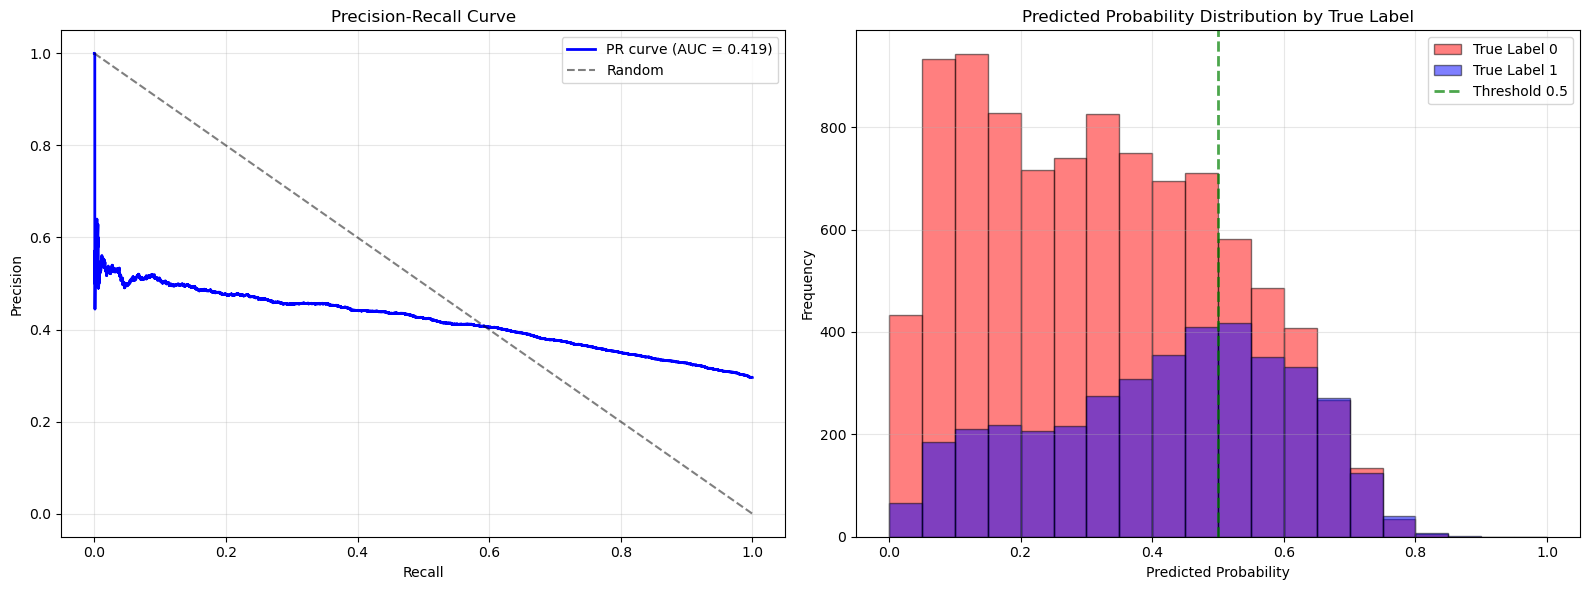

In [ ]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

测试集准确率: 0.6700

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77      5659
           1       0.44      0.43      0.44      2378

    accuracy                           0.67      8037
   macro avg       0.60      0.60      0.60      8037
weighted avg       0.67      0.67      0.67      8037

## 创建策略实例

In [ ]:
strategy = StrategyDemo(model, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

日期 20260303 完成，盈亏: 16.70, 成交: 24次
日期 20260304 完成，盈亏: -1.10, 成交: 30次
日期 20260305 完成，盈亏: -2.80, 成交: 22次
日期 20260306 完成，盈亏: -0.20, 成交: 12次

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
2

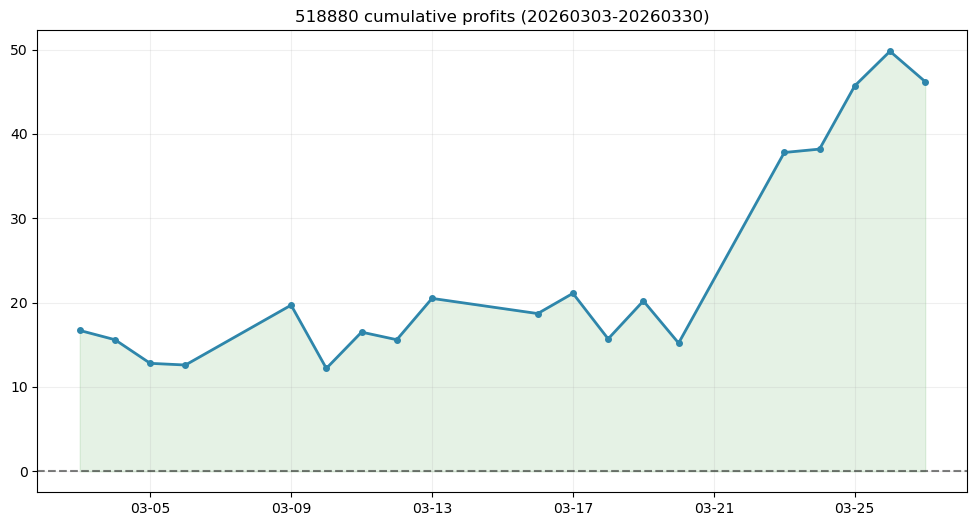

{'测试天数': 19, '累计总盈亏': np.float64(46.2), '总成交次数': 308, '日均盈亏': np.float64(2.43), '胜率(天)%': 52.63, '盈亏比(日均)': np.float64(2.37), '最大单日盈利': 22.6, '最大单日亏损': -7.5, '每笔交易平均盈利': np.float64(0.15)}


In [ ]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from multi_day_backtest import backtest_multi_days, backtest_summary
from delta.strategy import StrategyDemo

result_df = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd='20260303',
    end_ymd='20260330',
    StrategyClass= StrategyDemo,
    model = model,
    param_dict=param_dict,
    official = False
)

summary = backtest_summary(result_df)
print(summary)

In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(result_df)

,trade_ymd,profits,trades,trade_date
0,20260303,16.7,24,2026-03-03
1,20260304,-1.1,30,2026-03-04
2,20260305,-2.8,22,2026-03-05
3,20260306,-0.2,12,2026-03-06
4,20260309,7.1,21,2026-03-09
5,20260310,-7.5,12,2026-03-10
6,20260311,4.3,9,2026-03-11
7,20260312,-0.9,12,2026-03-12
8,20260313,4.9,8,2026-03-13
9,20260316,-1.8,14,2026-03-16


## 保存回测结果

In [ ]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果
result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260413_083327
回测结果已保存到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260413_083327
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [ ]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260408", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260408", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹

总共删除了 0 个文件夹


## 单日回测观察

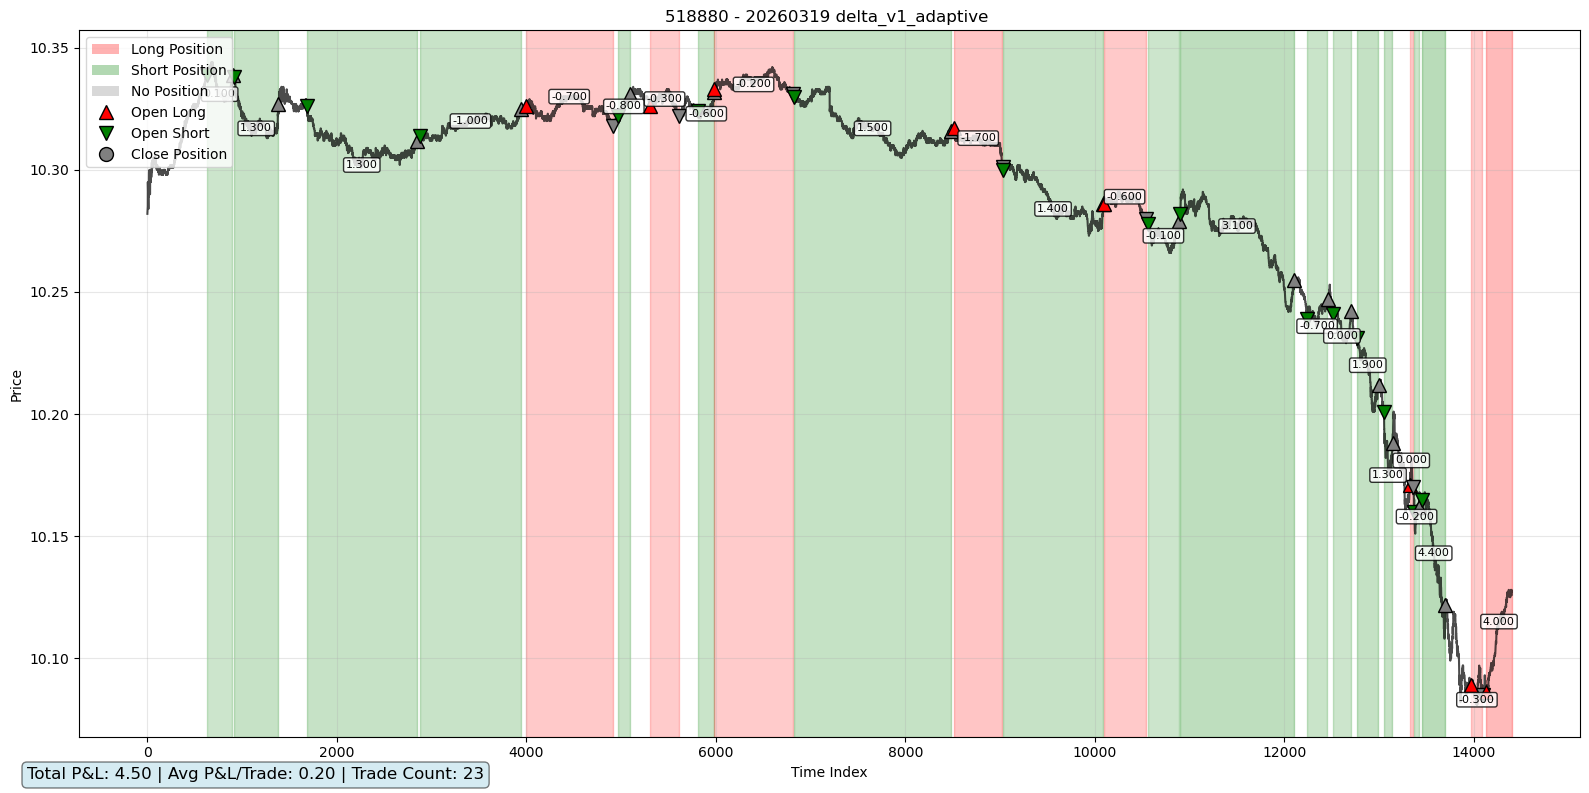

In [ ]:
from single_day_backtest import single_day_backtest
hh = single_day_backtest(instrument_id,'20260319',StrategyDemo,model,param_dict,official = False)